# 🤖 02 – Baseline ML: Hagyományos gépi tanulás

**Cél:** A GTZAN adathalmaz előre kiszámított feature-jeivel (`features_30_sec.csv`) gyors, interpretálható baseline modellek építése és összehasonlítása, mielőtt bonyolultabb mélytanulási megközelítésre váltanánk.

| Lépés | Eszköz |
|---|---|
| Feature betöltés | `pandas` |
| Előkészítés | `StandardScaler`, `train_test_split` |
| Modellek | `LogisticRegression`, `RandomForest`, `SVC` |
| Kiértékelés | `accuracy`, `classification_report`, `confusion_matrix` |
| Mentés | `joblib` |

> **Előfeltétel:** Futtasd le előbb a `01_EDA_with_theory.ipynb`-t, hogy megismerd az adathalmazt.


---
## 🧠 Elméleti háttér – Könyvtárak

| Könyvtár | Mire való? |
|---|---|
| `pandas` | Táblázatos adat betöltése és manipulálása |
| `numpy` | Numerikus műveletek |
| `sklearn` | ML modellek, előfeldolgozás, kiértékelés |
| `matplotlib` / `seaborn` | Vizualizáció |
| `joblib` | Modell mentése/betöltése (`.pkl` fájl) |


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# ── Útvonalak ────────────────────────────────────────────────────────────
WORKSPACE_DIR = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / 'data' / 'features_30_sec.csv').exists():
        WORKSPACE_DIR = candidate
        break

if WORKSPACE_DIR is None:
    WORKSPACE_DIR = Path.cwd().resolve()

CSV_30     = WORKSPACE_DIR / 'data' / 'features_30_sec.csv'
MODELS_DIR = WORKSPACE_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42  # reprodukálhatóság
TEST_SIZE    = 0.2 # 80% tanítás, 20% teszt

print('✅ Könyvtárak betöltve')
print(f'   CSV: {CSV_30}')
print(f'   Modell mappa: {MODELS_DIR}')


✅ Könyvtárak betöltve
   CSV: /home/feri/Asztal/gtzan-music-genre-recognition/data/features_30_sec.csv
   Modell mappa: /home/feri/Asztal/gtzan-music-genre-recognition/models


---
## 1. Adat betöltése és előkészítése

### 🧠 Elméleti háttér – X / y szétválasztás

Egy felügyelt tanulási feladathoz két dolgot kell elkülöníteni:

- **X (feature mátrix):** A bemeneti jellemzők – minden sor egy fájl, minden oszlop egy mért tulajdonság (pl. MFCC átlag, chroma, spectral centroid).
- **y (target vektor):** A helyes válasz – jelen esetben a műfaj neve (blues, classical, country, stb.).

A modell feladata: **megtanulni az X → y leképezést**, majd új, soha nem látott X-re is jó y-t jósolni.

#### Miért kell a `label` oszlopot kizárni X-ből?

Ha benne hagynánk, a modell 'puskázna': látná a helyes választ tanítás közben → 100% pontosság, de éles adaton 0%. Ezt nevezzük **data leakage**-nek.


In [5]:
# ── Adat betöltése ──────────────────────────────────────────────────────
df = pd.read_csv(CSV_30)

print(f'DataFrame mérete: {df.shape}')
print(f'Oszlopok: {df.columns.tolist()[:8]} ...')
print(f'Műfajok: {sorted(df["label"].unique())}')
print()

# ── X / y szétválasztás ──────────────────────────────────────────────────
# Kizárjuk: 'filename' (azonosító, nem jellemző) és 'label' (target)
EXCLUDE = ['filename', 'label']
feature_cols = [c for c in df.columns if c not in EXCLUDE]

X = df[feature_cols].values   # numpy tömb, (1000, n_features)
y = df['label'].values        # string array, (1000,)

print(f'Feature-ök száma: {X.shape[1]}')
print(f'Minták száma:     {X.shape[0]}')
print(f'Osztályok száma:  {len(np.unique(y))}')


DataFrame mérete: (1000, 60)
Oszlopok: ['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var'] ...
Műfajok: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

Feature-ök száma: 58
Minták száma:     1000
Osztályok száma:  10


---
### 🧠 Elméleti háttér – Train / Test split és Stratifikáció

Az adathalmazt **két részre** osztjuk:

| Rész | Arány | Mire való? |
|---|---|---|
| **Train set** | 80% (800 minta) | A modell ezen tanul |
| **Test set** | 20% (200 minta) | Ezen mérjük a valódi teljesítményt |

#### Miért `stratify=y`?

Stratifikáció nélkül előfordulhatna, hogy a teszt halmazba véletlenül kevés 'classical' de sok 'rock' kerül – ez torzítja az eredményt.  
`stratify=y` garantálja, hogy **minden műfajból pontosan 20%** kerüljön a teszt halmazba (= 20 fájl műfajonként).

#### Miért `random_state=42`?

A véletlen felosztás reprodukálható legyen – ha te és a tanárod ugyanazt a kódot futtatjátok, ugyanazt az eredményt kapjátok.


In [6]:
# ── Train / Test split ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y          # egyenlő műfaj-arány train és test halmazban
)

print(f'Train mérete: {X_train.shape}  ({len(X_train)} minta)')
print(f'Test mérete:  {X_test.shape}  ({len(X_test)} minta)')
print()

# Ellenőrzés: mindkét halmazban egyenlő arányban vannak a műfajok?
train_dist = pd.Series(y_train).value_counts().sort_index()
test_dist  = pd.Series(y_test).value_counts().sort_index()
print('Műfaj eloszlás – Train:')
print(train_dist.to_dict())
print('Műfaj eloszlás – Test:')
print(test_dist.to_dict())


Train mérete: (800, 58)  (800 minta)
Test mérete:  (200, 58)  (200 minta)

Műfaj eloszlás – Train:
{'blues': 80, 'classical': 80, 'country': 80, 'disco': 80, 'hiphop': 80, 'jazz': 80, 'metal': 80, 'pop': 80, 'reggae': 80, 'rock': 80}
Műfaj eloszlás – Test:
{'blues': 20, 'classical': 20, 'country': 20, 'disco': 20, 'hiphop': 20, 'jazz': 20, 'metal': 20, 'pop': 20, 'reggae': 20, 'rock': 20}


---
### 🧠 Elméleti háttér – StandardScaler (normalizálás)

Az EDA-ban láttuk, hogy a feature-ök nagyon különböző skálán mozognak:  
pl. `tempo` ~ 100–200, de `mfcc_1_mean` ~ -500–200.

A legtöbb ML algoritmus **érzékeny a skálára** – ha egy feature 1000x nagyobb számokat vesz fel, a modell azt fontosabbnak gondolhatja a valóságosnál.

**StandardScaler** minden feature-t átalakít úgy, hogy:

- `mean = 0` (átlag nulla)
- `std = 1` (szórás egy)

A képlet: `x_scaled = (x - mean) / std`

#### Fontos: csak train adaton illeszd a scalert!

| Lépés | Adathalmaz |
|---|---|
| `scaler.fit_transform(X_train)` | Train – megtanulja a mean/std értékeket |
| `scaler.transform(X_test)` | Test – **csak alkalmazza**, nem tanul belőle |

Ha a test adaton is `fit`-elnénk, 'belecsempésznénk' a teszt statisztikákat a modellbe → **data leakage**.


In [7]:
# ── StandardScaler ──────────────────────────────────────────────────────
scaler = StandardScaler()

# fit_transform: megtanulja a train mean/std-t ÉS átalakítja
X_train_sc = scaler.fit_transform(X_train)

# transform: csak alkalmazza a már megtanult mean/std-t
X_test_sc  = scaler.transform(X_test)

print('Skálázás előtt (X_train első feature):')
print(f'  mean={X_train[:,0].mean():.2f}  std={X_train[:,0].std():.2f}')
print('Skálázás után (X_train_sc első feature):')
print(f'  mean={X_train_sc[:,0].mean():.2f}  std={X_train_sc[:,0].std():.2f}')

# Scaler mentése – szükséges lesz a deployment során is!
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')
print('\n✅ Scaler mentve:', MODELS_DIR / 'scaler.pkl')


Skálázás előtt (X_train első feature):
  mean=662065.04  std=1872.33
Skálázás után (X_train_sc első feature):
  mean=0.00  std=1.00

✅ Scaler mentve: /home/feri/Asztal/gtzan-music-genre-recognition/models/scaler.pkl


---
## 2. Modellek

### 🧠 Elméleti háttér – Miért három modell?

Három nagyon különböző elvet képviselő modellt hasonlítunk össze – így látjuk, melyik típusú megközelítés illik legjobban az adathoz.

| Modell | Elv | Előny | Hátrány |
|---|---|---|---|
| **Logistic Regression** | Lineáris döntési határ | Gyors, interpretálható | Nem kezeli a nemlineáris összefüggéseket |
| **Random Forest** | Sok döntési fa szavazása | Erős, nincs skálázás igény | Lassabb, kevésbé interpretálható |
| **SVC** (kernel SVM) | Maximális margó, RBF kernel | Jól teljesít kis adaton | Lassú nagy adaton, érzékeny skálára |

#### Logistic Regression

Annak ellenére, hogy 'regression' a neve, **osztályozásra** való.  
Egy sigmoid (vagy softmax) függvénnyel valószínűséget számol minden osztályra, majd a legvalószínűbbet adja vissza.  
`max_iter=1000` – az optimalizáló algoritmusnak elegendő lépést adunk a konvergenciához.

#### Random Forest

100 döntési fát tanít (`n_estimators=100`), mindegyiket az adatok egy véletlenszerű részén. Az előrejelzés a 100 fa **szavazatának többsége**.  
Ez csökkenti az overfitting-et (a fák hibái 'kioljtják egymást').

#### SVC – Support Vector Classifier

A tanítópontok között a lehető **legtágabb sávot** (margót) keresi.  
`kernel='rbf'` – Radial Basis Function: a nemlineáris összefüggéseket is kezeli azáltal, hogy egy magasabb dimenziós térbe emeli az adatot.


In [8]:
# ── Modellek definiálása ─────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1           # párhuzamos futás minden CPU magon
    ),
    'SVC (RBF kernel)': SVC(
        kernel='rbf',
        C=10,               # regularizáció erőssége (nagyobb C = kevésbé megengedő)
        gamma='scale',      # RBF szélessége – 'scale' = 1/(n_features * X.var())
        random_state=RANDOM_STATE
    ),
}

# ── Tanítás és kiértékelés ───────────────────────────────────────────────
results = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred   = model.predict(X_test_sc)
    acc      = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'y_pred': y_pred, 'accuracy': acc}
    print(f'{name:25s} → Test accuracy: {acc:.4f} ({acc*100:.2f}%)')

print()
best_name = max(results, key=lambda k: results[k]['accuracy'])
print(f'⭐ Legjobb modell: {best_name}  ({results[best_name]["accuracy"]*100:.2f}%)')


Logistic Regression       → Test accuracy: 0.7400 (74.00%)
Random Forest             → Test accuracy: 0.7750 (77.50%)
SVC (RBF kernel)          → Test accuracy: 0.7650 (76.50%)

⭐ Legjobb modell: Random Forest  (77.50%)


---
## 3. Részletes kiértékelés

### 🧠 Elméleti háttér – classification_report metrikák

Az `accuracy` (összesített pontosság) egyetlen számba sűríti az eredményt, de elrejti, hogy **melyik műfajnál** hibázik a modell.  
A `classification_report` műfajonként mutatja:

| Metrika | Képlet | Mit mér? |
|---|---|---|
| **Precision** | TP / (TP + FP) | A 'blues'-nak jósolt fájlok hány %-a tényleg blues? |
| **Recall** | TP / (TP + FN) | Az összes blues fájl hány %-át találta meg? |
| **F1-score** | 2·P·R / (P+R) | A precision és recall harmonikus átlaga |
| **Support** | – | Hány teszt minta van ebből az osztályból |

**TP** = True Positive, **FP** = False Positive, **FN** = False Negative

> **Zenei kontextusban:** Ha a modell a 'rock' fájlokat sokszor összetéveszti 'metal'-lal, alacsony precision/recall lesz a rock osztálynál – ez az EDA-ban látott waveform-hasonlóságot tükrözi.


In [9]:
# ── Classification report: legjobb modell ───────────────────────────────
print(f'=== {best_name} – Classification Report ===')
print(classification_report(
    y_test,
    results[best_name]['y_pred'],
    digits=3
))


=== Random Forest – Classification Report ===
              precision    recall  f1-score   support

       blues      0.789     0.750     0.769        20
   classical      0.864     0.950     0.905        20
     country      0.714     0.750     0.732        20
       disco      0.706     0.600     0.649        20
      hiphop      0.652     0.750     0.698        20
        jazz      0.773     0.850     0.810        20
       metal      0.895     0.850     0.872        20
         pop      0.857     0.900     0.878        20
      reggae      0.762     0.800     0.780        20
        rock      0.733     0.550     0.629        20

    accuracy                          0.775       200
   macro avg      0.775     0.775     0.772       200
weighted avg      0.775     0.775     0.772       200



---
### 🧠 Elméleti háttér – Konfúziós mátrix

A konfúziós mátrix egy **10×10-es táblázat** (10 műfaj × 10 műfaj).  
Minden cella azt mutatja: a valódi műfajú (sor) fájlokat mibe jósolta a modell (oszlop).

```
         ← jósolt →
       blues  classic  ...
blues  [ 18      0   ]   ← a blues fájlokból 18-at helyesen, 0-t classicalnak jósolt
classic[  0     20   ]
```

- **Átló** (bal felső → jobb alsó): helyes jóslatok → minél sötétebb, annál jobb
- **Átlón kívüli magas értékek:** ott keveri össze a modell a két műfajt

**Tipikus GTZAN tévesztések** (irodalomból ismert):
- country ↔ rock (hasonló hangszerelés)
- jazz ↔ classical (hasonló tempó, dinamika)
- disco ↔ pop (hasonló ritmus)


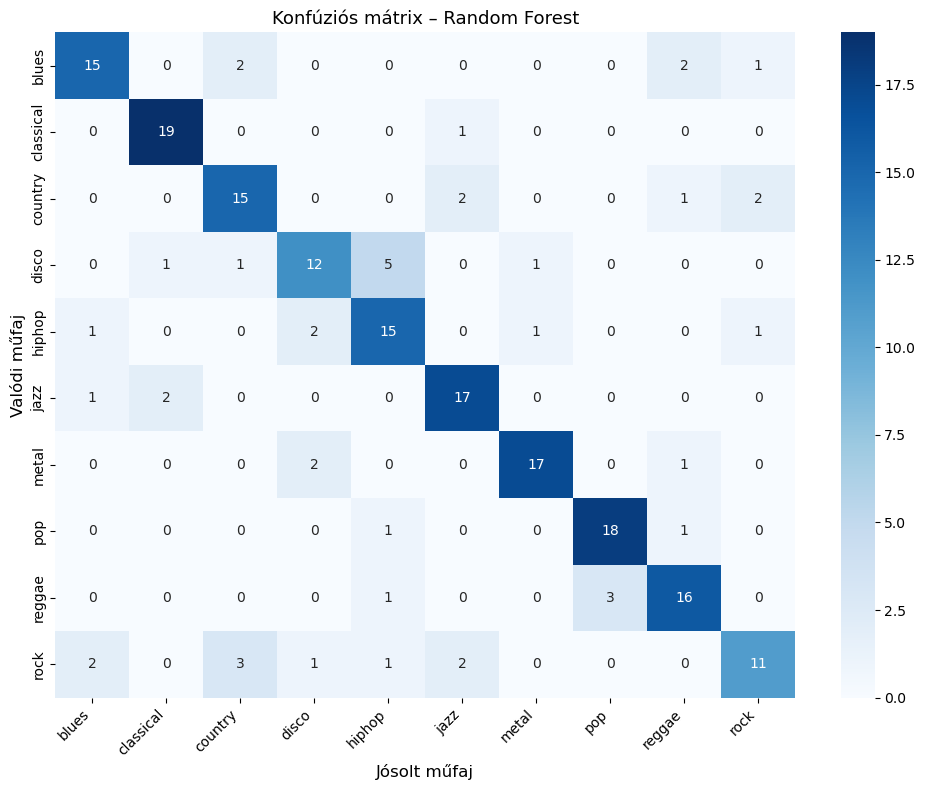

In [10]:
# ── Konfúziós mátrix – legjobb modell ──────────────────────────────────
GENRES = sorted(np.unique(y))
cm = confusion_matrix(y_test, results[best_name]['y_pred'], labels=GENRES)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,       # számok megjelenítése minden cellában
    fmt='d',          # egész szám formátum
    cmap='Blues',
    xticklabels=GENRES,
    yticklabels=GENRES,
    ax=ax
)
ax.set_xlabel('Jósolt műfaj', fontsize=12)
ax.set_ylabel('Valódi műfaj', fontsize=12)
ax.set_title(f'Konfúziós mátrix – {best_name}', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'confusion_matrix_baseline.png', dpi=100, bbox_inches='tight')
plt.show()


---
### 🧠 Elméleti háttér – Modellek összehasonlítása

A három modell eredményét egymás mellé helyezve látható, hogy **melyik baseline érdemes a Szint 2 (Ensemble) kiindulópontjaként**.

Általános elvárások GTZAN 30s CSV feature-ökkel:

| Modell | Tipikus accuracy |
|---|---|
| Logistic Regression | 65–72% |
| Random Forest | 78–85% |
| SVC (RBF) | 78–87% |

Ha az eredményeid ezen a tartományon belül vannak, a kód és az adatok rendben vannak.  
Ha jóval alacsonyabb, érdemes megnézni a feature skálázást és a hyperparamétereket.


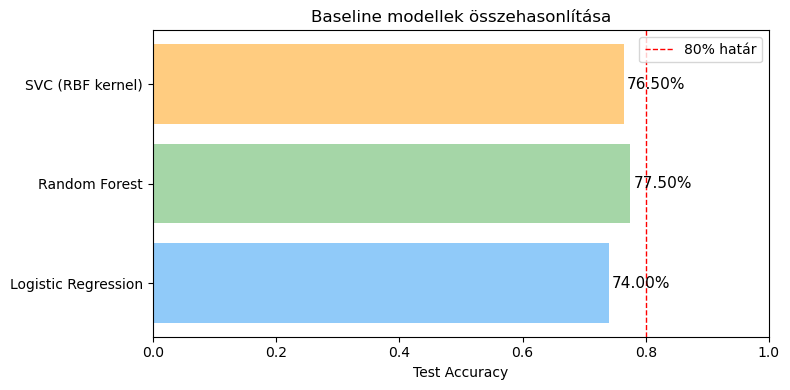

In [11]:
# ── Modellek összehasonlítása ────────────────────────────────────────────
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(names, accs, color=['#90CAF9', '#A5D6A7', '#FFCC80'])
ax.set_xlim(0, 1)
ax.set_xlabel('Test Accuracy')
ax.set_title('Baseline modellek összehasonlítása')
ax.axvline(0.8, color='red', linestyle='--', linewidth=1, label='80% határ')
ax.legend()
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{acc*100:.2f}%', va='center', fontsize=11)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'baseline_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


---
### 🧠 Elméleti háttér – Feature importancia (Random Forest)

A Random Forest megmondja, hogy **melyik feature volt a leghasznosabb** a döntéshozatalhoz.  
Ez úgy számítódik, hogy minden fánál megméri: ha egy feature szerint osztjuk szét az adatot, mennyivel csökken a 'rendetlenség' (Gini impurity) az egyes csomópontokban.

**Magas importancia** = a modell sokat támaszkodott erre a jellemzőre.

> **Hasznos a CNN-es fázishoz:** Ha az MFCC jellemzők dominálnak, ez megerősíti, hogy érdemes Mel-spektrogramot használni a CNN bemenetéhez.


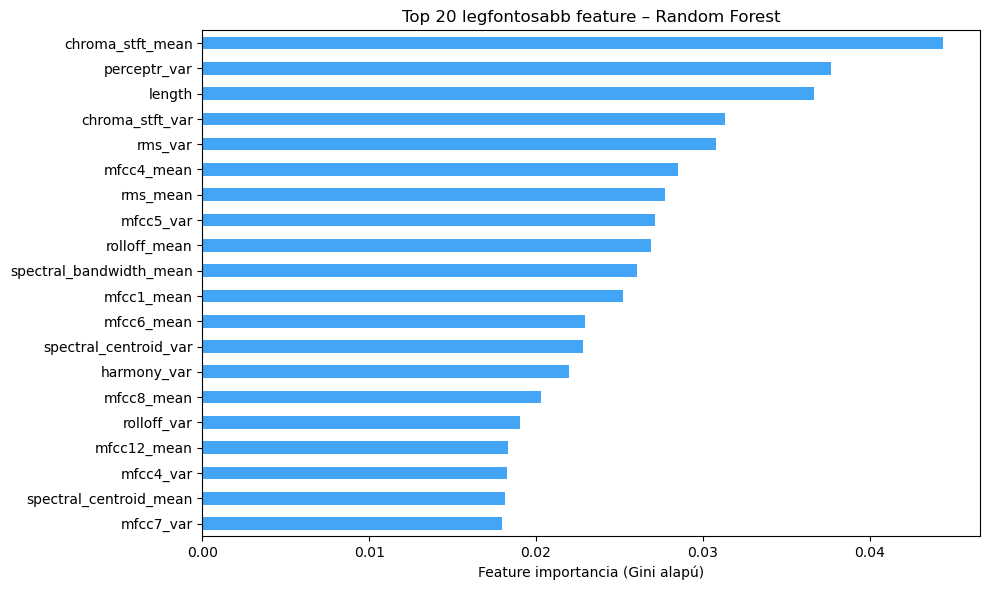

Top 10 feature:
  chroma_stft_mean                     0.0444
  perceptr_var                         0.0377
  length                               0.0366
  chroma_stft_var                      0.0313
  rms_var                              0.0308
  mfcc4_mean                           0.0285
  rms_mean                             0.0277
  mfcc5_var                            0.0271
  rolloff_mean                         0.0269
  spectral_bandwidth_mean              0.0260


In [12]:
# ── Feature importancia – Random Forest ─────────────────────────────────
rf_model = results['Random Forest']['model']
importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

top_n = 20
fig, ax = plt.subplots(figsize=(10, 6))
importances.head(top_n).plot(kind='barh', ax=ax, color='#42A5F5')
ax.invert_yaxis()
ax.set_xlabel('Feature importancia (Gini alapú)')
ax.set_title(f'Top {top_n} legfontosabb feature – Random Forest')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'feature_importance_rf.png', dpi=100, bbox_inches='tight')
plt.show()

print('Top 10 feature:')
for feat, imp in importances.head(10).items():
    print(f'  {feat:35s}  {imp:.4f}')


---
## 4. Modell mentése

### 🧠 Elméleti háttér – `joblib` vs `pickle`

Két fő módszer van Python objektumok elmentésére:

| | `joblib` | `pickle` |
|---|---|---|
| Nagy numpy tömbök | ✅ Hatékony | ⚠ Lassabb |
| sklearn modellek | ✅ Ajánlott | ✅ Működik |
| Fájlméret | Kisebb | Nagyobb |

**Miért kell elmenteni?**  
Hogy ne kelljen minden alkalommal újra tanítani. A mentett `.pkl` fájlt betöltve azonnal jósolhatsz – ez lesz az alap a Streamlit apphoz is.

**Mentjük a scaler-t is!**  
Deployment során az új hangfájlokra ugyanazt a skálázást kell alkalmazni, amit a tanítóadaton tanultunk. Ha elfelejtjük, a jóslatok helytelennek lesznek.


In [13]:
# ── Legjobb modell mentése ───────────────────────────────────────────────
best_model = results[best_name]['model']

# Fájlnév: szóközök helyett aláhúzás, kisbetűs
safe_name  = best_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
model_path = MODELS_DIR / f'baseline_{safe_name}.pkl'

joblib.dump(best_model, model_path)
print(f'✅ Modell mentve:  {model_path}')
print(f'   Scaler mentve:  {MODELS_DIR / "scaler.pkl"}')
print()

# ── Betöltés ellenőrzése ─────────────────────────────────────────────────
loaded_model  = joblib.load(model_path)
loaded_scaler = joblib.load(MODELS_DIR / 'scaler.pkl')
y_check = loaded_model.predict(loaded_scaler.transform(X_test))
acc_check = accuracy_score(y_test, y_check)
print(f'✅ Betöltés ellenőrzés: {acc_check*100:.2f}%  '
      f'{"✅ Egyezik" if abs(acc_check - results[best_name]["accuracy"]) < 1e-6 else "❌ Eltérés!"}')


✅ Modell mentve:  /home/feri/Asztal/gtzan-music-genre-recognition/models/baseline_random_forest.pkl
   Scaler mentve:  /home/feri/Asztal/gtzan-music-genre-recognition/models/scaler.pkl

✅ Betöltés ellenőrzés: 77.50%  ✅ Egyezik


---
## 5. Összefoglaló és következő lépések

Az alábbi cella összegzi az eredményeket és megmondja, érdemes-e továbblépni a mélytanulásra.


In [14]:
print('=' * 55)
print('        BASELINE ML ÖSSZEFOGLALÓ – GTZAN')
print('=' * 55)
for name, r in results.items():
    marker = ' ⭐' if name == best_name else ''
    print(f'  {name:25s}  {r["accuracy"]*100:.2f}%{marker}')
print()
best_acc = results[best_name]['accuracy']
print(f'  Legjobb baseline:  {best_acc*100:.2f}%')
print()
if best_acc >= 0.85:
    print('  ✅ Erős baseline – a CNN javulása már kisebb lesz,')
    print('     de a spektrogram-alapú megközelítés még mindig indokolt.')
elif best_acc >= 0.75:
    print('  ✅ Jó baseline – CNN várhatóan 5-15%-ot javít.')
else:
    print('  ⚠ Gyenge baseline – ellenőrizd a feature skálázást!')
print()
print('  Következő lépés: 03_CNN_Model.ipynb')
print('   → Mel-spektrogram képek generálása')
print('   → VGG-stílusú CNN architektúra')
print('   → Transfer learning opció (VGG16 / ResNet)')
print('=' * 55)


        BASELINE ML ÖSSZEFOGLALÓ – GTZAN
  Logistic Regression        74.00%
  Random Forest              77.50% ⭐
  SVC (RBF kernel)           76.50%

  Legjobb baseline:  77.50%

  ✅ Jó baseline – CNN várhatóan 5-15%-ot javít.

  Következő lépés: 03_CNN_Model.ipynb
   → Mel-spektrogram képek generálása
   → VGG-stílusú CNN architektúra
   → Transfer learning opció (VGG16 / ResNet)
